# PyTorch 기반 1차원 이차함수 회귀 신경망 실습

이 노트북은 `y = x² + 3` 형태의 이차함수 데이터를 생성한 뒤, PyTorch 신경망이 해당 곡선 형태를 학습하도록 구성한 실습 자료입니다.

기존 코드의 핵심 목적은 다음과 같습니다.

1. 임의의 `x` 값을 생성한다.
2. `y = x² + 3` 공식을 이용해 정답 데이터를 만든다.
3. 실제 데이터처럼 보이도록 노이즈를 추가한다.
4. 완전연결 신경망을 만들어 `x → y` 관계를 학습한다.
5. 학습 후 예측 곡선과 손실 그래프를 시각화한다.

이 코드는 단순 선형회귀로는 표현하기 어려운 곡선 데이터를 신경망이 어떻게 학습하는지 확인하기 위한 예제입니다.

## 1. 라이브러리 불러오기

이 단계에서는 데이터 생성, 신경망 구성, 모델 학습, 시각화에 필요한 라이브러리를 불러옵니다.

- `torch`는 Tensor 연산과 딥러닝 모델 학습에 사용합니다.
- `torch.nn`은 신경망 계층과 손실 함수를 만들 때 사용합니다.
- `torch.optim`은 가중치와 편향을 업데이트하는 최적화 알고리즘을 제공합니다.
- `matplotlib.pyplot`은 데이터와 학습 결과를 그래프로 확인할 때 사용합니다.

In [1]:
# NumPy는 수치 계산과 배열 처리를 위해 사용하는 라이브러리입니다.
import numpy as np

# PyTorch의 핵심 라이브러리로, Tensor 생성과 연산을 담당합니다.
import torch

# torch.nn은 Linear, ReLU, Loss 함수 등 신경망 구성 요소를 제공합니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# matplotlib.pyplot은 산점도, 선 그래프 등 시각화를 위해 사용합니다.
import matplotlib.pyplot as plt

# random 모듈은 Python 기본 난수 생성을 제어할 때 사용합니다.
import random

## 2. 실행 환경과 난수 고정

딥러닝 코드는 난수 초기화에 따라 실행할 때마다 결과가 조금 달라질 수 있습니다.  
수업에서는 같은 코드를 실행했을 때 비슷한 결과가 나오도록 난수 시드를 고정하는 것이 좋습니다.

또한 GPU가 있으면 GPU를 사용하고, GPU가 없으면 CPU를 사용하도록 장치를 자동으로 선택합니다.

In [2]:
# Python 기본 random 모듈의 난수 시드를 42로 고정합니다.
random.seed(42)

# NumPy 난수 시드를 42로 고정하여 NumPy 기반 난수 결과를 재현 가능하게 합니다.
np.random.seed(42)

# PyTorch CPU 연산의 난수 시드를 42로 고정합니다.
torch.manual_seed(42)

# CUDA GPU가 사용 가능한 경우 GPU 연산의 난수 시드도 42로 고정합니다.
torch.cuda.manual_seed_all(42)

# CUDA GPU가 있으면 'cuda'를 사용하고, 없으면 'cpu'를 사용하도록 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용 중인 연산 장치를 출력합니다.
print("사용 장치:", device)

사용 장치: cpu


## 3. 하이퍼파라미터 설정

하이퍼파라미터는 모델이 직접 학습하는 값이 아니라, 사람이 학습 전에 정하는 설정값입니다.

이 코드에서는 다음 값을 설정합니다.

- `num_data`: 생성할 데이터 개수
- `num_epoch`: 전체 학습 반복 횟수
- `learning_rate`: 한 번 업데이트할 때 가중치를 얼마나 크게 수정할지 결정하는 값

In [3]:
# 학습에 사용할 데이터 개수를 1000개로 설정합니다.
num_data = 1000

# 전체 데이터를 몇 번 반복해서 학습할지 설정합니다.
num_epoch = 5000

# SGD 최적화 알고리즘에서 사용할 학습률을 설정합니다.
learning_rate = 0.0005

# 설정된 하이퍼파라미터 값을 확인하기 위해 출력합니다.
print("데이터 개수:", num_data)

# 설정된 학습 반복 횟수를 출력합니다.
print("학습 반복 횟수:", num_epoch)

# 설정된 학습률을 출력합니다.
print("학습률:", learning_rate)

데이터 개수: 1000
학습 반복 횟수: 5000
학습률: 0.0005


## 4. 이차함수 데이터 생성

이 단계는 신경망이 학습할 데이터를 만드는 과정입니다.

원래 관계식은 다음과 같습니다.

\[
y = x^2 + 3
\]

여기에 노이즈를 추가하여 실제 데이터처럼 조금 흔들리는 값을 만듭니다.  
딥러닝 모델은 노이즈가 포함된 데이터에서 전체적인 곡선 패턴을 학습해야 합니다.

In [4]:
# 평균 0, 표준편차 1인 정규분포 노이즈를 생성합니다.
noise = torch.randn(num_data, 1) * 1.0

# -15부터 15 사이의 균등분포에서 입력값 x를 1000개 생성합니다.
x = torch.empty(num_data, 1).uniform_(-15, 15)

# 정답 곡선 y = x^2 + 3을 계산합니다.
y = (x ** 2) + 3

# 정답 y에 노이즈를 더해 실제 관측값처럼 흔들리는 데이터를 만듭니다.
y_noise = y + noise

# x Tensor의 크기를 출력하여 데이터가 1000행 1열인지 확인합니다.
print("x 크기:", x.size())

# y Tensor의 크기를 출력하여 정답 데이터가 1000행 1열인지 확인합니다.
print("y 크기:", y.size())

# y_noise Tensor의 크기를 출력하여 노이즈가 포함된 정답 데이터 크기를 확인합니다.
print("노이즈 포함 y 크기:", y_noise.size())

x 크기: torch.Size([1000, 1])
y 크기: torch.Size([1000, 1])
노이즈 포함 y 크기: torch.Size([1000, 1])


## 5. 생성된 데이터 시각화

이 단계에서는 생성된 데이터를 그래프로 확인합니다.

- 파란 점은 노이즈가 포함된 학습 데이터입니다.
- 검은 선은 원래 정답 함수 `y = x² + 3`입니다.

이 그래프를 통해 모델이 어떤 곡선을 학습해야 하는지 직관적으로 확인할 수 있습니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

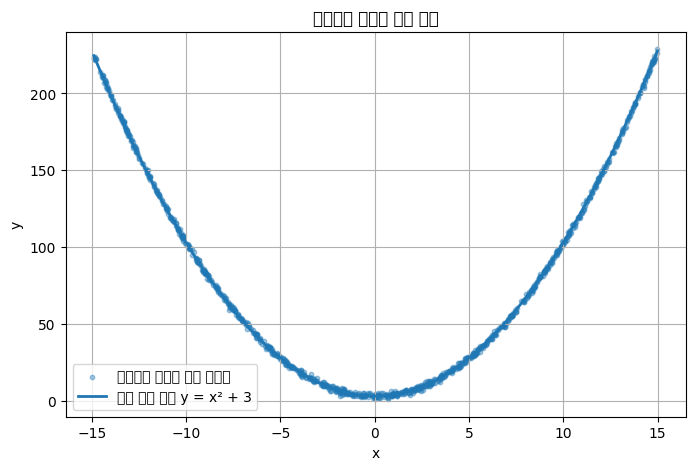

In [5]:
# 그래프 크기를 가로 8, 세로 5로 설정합니다.
plt.figure(figsize=(8, 5))

# 노이즈가 포함된 데이터를 산점도로 표시합니다.
plt.scatter(x.numpy(), y_noise.numpy(), s=10, alpha=0.4, label="노이즈가 포함된 학습 데이터")

# x 값을 기준으로 정렬하기 위해 x를 1차원으로 변환한 뒤 정렬 인덱스를 구합니다.
sorted_indices = torch.argsort(x.squeeze())

# 정렬된 x 값을 가져옵니다.
x_sorted = x[sorted_indices]

# 정렬된 x에 해당하는 원래 정답 y 값을 가져옵니다.
y_sorted = y[sorted_indices]

# 원래 정답 함수 y = x^2 + 3을 선 그래프로 표시합니다.
plt.plot(x_sorted.numpy(), y_sorted.numpy(), linewidth=2, label="실제 정답 곡선 y = x² + 3")

# 그래프 제목을 설정합니다.
plt.title("이차함수 데이터 생성 결과")

# x축 이름을 설정합니다.
plt.xlabel("x")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시하여 값을 읽기 쉽게 만듭니다.
plt.grid(True)

# 그래프를 화면에 출력합니다.
plt.show()

## 6. 데이터를 학습 장치로 이동

PyTorch에서는 모델과 데이터가 같은 장치에 있어야 연산할 수 있습니다.

예를 들어 모델은 GPU에 있고 데이터는 CPU에 있으면 오류가 발생합니다.  
따라서 입력 데이터와 정답 데이터를 앞에서 설정한 `device`로 이동합니다.

In [6]:
# 입력 데이터 x를 CPU 또는 GPU 장치로 이동합니다.
x_train = x.to(device)

# 노이즈가 포함된 정답 데이터 y_noise를 CPU 또는 GPU 장치로 이동합니다.
y_train = y_noise.to(device)

# 시각화용 원본 정답 y도 같은 장치로 이동합니다.
y_true = y.to(device)

# 입력 데이터가 어느 장치에 있는지 출력합니다.
print("x_train 장치:", x_train.device)

# 정답 데이터가 어느 장치에 있는지 출력합니다.
print("y_train 장치:", y_train.device)

x_train 장치: cpu
y_train 장치: cpu


## 7. 신경망 모델 정의

이 모델은 입력값 1개를 받아 출력값 1개를 예측하는 회귀 모델입니다.

구조는 다음과 같습니다.

```text
입력층(1)
 → 은닉층(6)
 → ReLU
 → 은닉층(10)
 → ReLU
 → 은닉층(6)
 → ReLU
 → 출력층(1)
```

이차함수는 직선 하나로 표현하기 어렵기 때문에 여러 개의 은닉층과 ReLU 활성화 함수를 사용하여 곡선 형태를 학습하도록 합니다.

In [7]:
# nn.Sequential은 여러 계층을 순서대로 연결하여 신경망을 쉽게 구성하게 해줍니다.
model = nn.Sequential(
    # 입력값 1개를 받아 6개의 은닉 뉴런으로 변환하는 첫 번째 완전연결층입니다.
    nn.Linear(1, 6),

    # ReLU 활성화 함수는 음수는 0으로 만들고 양수는 그대로 통과시켜 비선형성을 추가합니다.
    nn.ReLU(),

    # 6개의 입력 특징을 받아 10개의 은닉 뉴런으로 변환하는 두 번째 완전연결층입니다.
    nn.Linear(6, 10),

    # 두 번째 은닉층의 출력에도 ReLU 활성화 함수를 적용합니다.
    nn.ReLU(),

    # 10개의 입력 특징을 받아 6개의 은닉 뉴런으로 변환하는 세 번째 완전연결층입니다.
    nn.Linear(10, 6),

    # 세 번째 은닉층의 출력에도 ReLU 활성화 함수를 적용합니다.
    nn.ReLU(),

    # 6개의 은닉 특징을 받아 최종 예측값 1개를 출력하는 출력층입니다.
    nn.Linear(6, 1)
)

# 모델을 CPU 또는 GPU 장치로 이동합니다.
model = model.to(device)

# 모델 구조를 출력하여 계층 구성이 올바른지 확인합니다.
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=6, bias=True)
  (1): ReLU()
  (2): Linear(in_features=6, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=6, bias=True)
  (5): ReLU()
  (6): Linear(in_features=6, out_features=1, bias=True)
)


## 8. 손실 함수와 최적화 알고리즘 설정

모델을 학습하려면 두 가지가 필요합니다.

첫째, 예측이 얼마나 틀렸는지 계산하는 손실 함수가 필요합니다.  
이 예제에서는 `L1Loss`를 사용합니다. `L1Loss`는 실제값과 예측값 차이의 절대값 평균을 계산합니다.

둘째, 계산된 오차를 바탕으로 가중치와 편향을 수정하는 최적화 알고리즘이 필요합니다.  
여기서는 원본 코드와 같은 `SGD`를 사용합니다.

In [8]:
# L1Loss는 예측값과 실제값 차이의 절대값 평균을 계산하는 회귀 손실 함수입니다.
loss_func = nn.L1Loss()

# SGD는 가장 기본적인 경사하강법 기반 최적화 알고리즘입니다.
optimizer = optim.SGD(
    # model.parameters()는 모델 내부의 모든 가중치와 편향을 optimizer에 전달합니다.
    model.parameters(),

    # lr은 learning rate이며, 한 번에 가중치를 얼마나 수정할지 결정합니다.
    lr=learning_rate
)

# 손실 함수 정보를 출력합니다.
print("손실 함수:", loss_func)

# 최적화 알고리즘 정보를 출력합니다.
print("최적화 알고리즘:", optimizer)

손실 함수: L1Loss()
최적화 알고리즘: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## 9. 학습 전 예측 결과 확인

학습 전 모델은 아직 데이터를 학습하지 않았으므로 예측 결과가 좋지 않습니다.

이 단계는 학습 전 상태를 확인하기 위한 코드입니다.  
학습 전과 학습 후를 비교하면 신경망이 실제로 곡선을 학습했는지 더 쉽게 이해할 수 있습니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

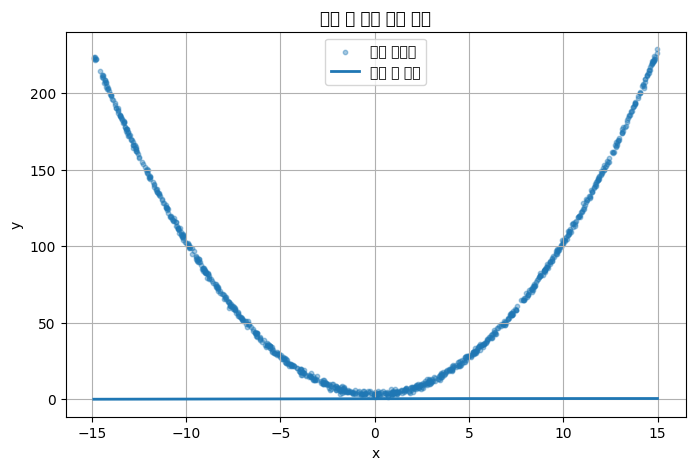

In [9]:
# torch.no_grad()는 그래디언트 계산을 끄는 문맥 관리자입니다.
with torch.no_grad():
    # 학습 전 모델에 입력 데이터를 넣어 예측값을 계산합니다.
    before_train_output = model(x_train)

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# 노이즈가 포함된 학습 데이터를 산점도로 표시합니다.
plt.scatter(x.numpy(), y_noise.numpy(), s=10, alpha=0.4, label="학습 데이터")

# 학습 전 모델의 예측값을 x 순서에 맞춰 선 그래프로 표시합니다.
plt.plot(
    x_sorted.numpy(),
    before_train_output.detach().cpu()[sorted_indices].numpy(),
    linewidth=2,
    label="학습 전 예측"
)

# 그래프 제목을 설정합니다.
plt.title("학습 전 모델 예측 결과")

# x축 이름을 설정합니다.
plt.xlabel("x")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 10. 모델 학습

이 단계가 딥러닝의 핵심 학습 과정입니다.

학습 과정은 다음 순서로 반복됩니다.

1. 모델이 입력값 `x`를 보고 예측값을 만든다.
2. 예측값과 실제값을 비교하여 손실을 계산한다.
3. 이전 반복에서 남아 있던 gradient를 초기화한다.
4. 역전파를 수행하여 각 가중치와 편향의 gradient를 계산한다.
5. optimizer가 gradient를 이용하여 가중치와 편향을 수정한다.

이 과정을 5000번 반복하면서 모델은 점점 이차함수 곡선에 가까운 예측을 하게 됩니다.

In [10]:
# 학습 과정에서 매 epoch마다 손실값을 저장할 리스트를 생성합니다.
loss_arr = []

# 지정한 epoch 횟수만큼 학습을 반복합니다.
for epoch in range(num_epoch):
    # 모델에 x_train을 입력하여 현재 가중치 기준의 예측값을 계산합니다.
    output = model(x_train)

    # 예측값 output과 실제값 y_train 사이의 손실을 계산합니다.
    loss = loss_func(output, y_train)

    # 이전 epoch에서 계산되어 남아 있는 gradient를 모두 0으로 초기화합니다.
    optimizer.zero_grad()

    # 손실값을 기준으로 역전파를 수행하여 각 파라미터의 gradient를 계산합니다.
    loss.backward()

    # 계산된 gradient를 이용하여 모델의 가중치와 편향을 업데이트합니다.
    optimizer.step()

    # 현재 손실값을 Python 숫자 형태로 변환하여 리스트에 저장합니다.
    loss_arr.append(loss.item())

    # 100 epoch마다 현재 학습 상태를 출력합니다.
    if epoch % 100 == 0:
        # epoch 번호와 현재 손실값을 보기 좋게 출력합니다.
        print(f"Epoch [{epoch:4d}/{num_epoch}]  Loss: {loss.item():.6f}")

Epoch [   0/5000]  Loss: 75.538765
Epoch [ 100/5000]  Loss: 75.266205
Epoch [ 200/5000]  Loss: 74.931282
Epoch [ 300/5000]  Loss: 74.465797
Epoch [ 400/5000]  Loss: 73.671425
Epoch [ 500/5000]  Loss: 71.989136
Epoch [ 600/5000]  Loss: 67.035057
Epoch [ 700/5000]  Loss: 44.235394
Epoch [ 800/5000]  Loss: 22.667564
Epoch [ 900/5000]  Loss: 21.972309
Epoch [1000/5000]  Loss: 21.518122
Epoch [1100/5000]  Loss: 21.070660
Epoch [1200/5000]  Loss: 20.637934
Epoch [1300/5000]  Loss: 20.214670
Epoch [1400/5000]  Loss: 19.818743
Epoch [1500/5000]  Loss: 19.431391
Epoch [1600/5000]  Loss: 19.031647
Epoch [1700/5000]  Loss: 18.613432
Epoch [1800/5000]  Loss: 18.181044
Epoch [1900/5000]  Loss: 17.720919
Epoch [2000/5000]  Loss: 17.224548
Epoch [2100/5000]  Loss: 16.708128
Epoch [2200/5000]  Loss: 16.191538
Epoch [2300/5000]  Loss: 15.666465
Epoch [2400/5000]  Loss: 15.112230
Epoch [2500/5000]  Loss: 14.536064
Epoch [2600/5000]  Loss: 13.903326
Epoch [2700/5000]  Loss: 13.220602
Epoch [2800/5000]  L

## 11. 학습된 파라미터 확인

신경망은 학습 과정에서 각 계층의 가중치와 편향을 자동으로 수정합니다.

이 단계에서는 학습된 `weight`와 `bias`를 확인합니다.  
출력되는 값은 모델이 이차함수 데이터를 예측하기 위해 내부적으로 학습한 값입니다.

In [11]:
# model.named_parameters()는 각 파라미터의 이름과 값을 함께 반환합니다.
for name, param in model.named_parameters():
    # 현재 파라미터의 이름을 출력합니다.
    print("파라미터 이름:", name)

    # 현재 파라미터의 크기를 출력합니다.
    print("파라미터 크기:", param.shape)

    # 현재 파라미터의 실제 값을 출력합니다.
    print(param.data)

    # 파라미터 사이를 구분하기 위한 선을 출력합니다.
    print("-" * 80)

파라미터 이름: 0.weight
파라미터 크기: torch.Size([6, 1])
tensor([[ 1.0666],
        [-0.2294],
        [-1.0029],
        [ 0.2316],
        [ 0.2484],
        [-0.1247]])
--------------------------------------------------------------------------------
파라미터 이름: 0.bias
파라미터 크기: torch.Size([6])
tensor([-1.0277, -1.9620, -0.8398,  0.0766, -1.9700, -0.8469])
--------------------------------------------------------------------------------
파라미터 이름: 2.weight
파라미터 크기: torch.Size([10, 6])
tensor([[ 0.5656,  0.6842,  0.8418,  0.3246,  0.3823,  0.0408],
        [-0.0866, -0.2925, -0.1102, -0.3341,  0.1553,  0.2889],
        [ 0.2767, -0.2923, -0.3098, -0.1278,  0.3630,  0.0100],
        [-0.0027,  0.2686,  0.0157,  0.0805, -0.0935,  0.1761],
        [ 0.2598, -0.3675, -0.2414,  0.0374,  0.3308,  0.1986],
        [-0.2286, -0.4067, -0.0332, -0.0356,  0.1185, -0.1126],
        [ 0.6056,  1.3795,  0.5594, -0.3187,  1.5967,  0.5477],
        [-0.2042,  0.2024, -0.4017,  0.3301,  0.0329,  0.0394],
        [ 0.61

## 12. 학습 후 예측 결과 시각화

학습이 끝난 뒤 모델이 만든 예측 곡선을 확인합니다.

모델이 잘 학습했다면 예측 곡선은 노이즈가 포함된 점들의 중심을 따라가며, 원래 이차함수 곡선과 비슷한 형태를 보여야 합니다.

In [ ]:
# torch.no_grad()를 사용하여 예측 과정에서 불필요한 gradient 계산을 막습니다.
with torch.no_grad():
    # 학습이 완료된 모델로 전체 입력 데이터에 대한 예측값을 계산합니다.
    trained_output = model(x_train)

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# 노이즈가 포함된 학습 데이터를 산점도로 표시합니다.
plt.scatter(x.numpy(), y_noise.numpy(), s=10, alpha=0.4, label="노이즈가 포함된 학습 데이터")

# 원래 정답 곡선을 선 그래프로 표시합니다.
plt.plot(x_sorted.numpy(), y_sorted.numpy(), linewidth=2, label="실제 정답 곡선 y = x² + 3")

# 학습된 모델의 예측값을 선 그래프로 표시합니다.
plt.plot(
    x_sorted.numpy(),
    trained_output.detach().cpu()[sorted_indices].numpy(),
    linewidth=2,
    label="학습 후 모델 예측 곡선"
)

# 그래프 제목을 설정합니다.
plt.title("학습 후 모델 예측 결과")

# x축 이름을 설정합니다.
plt.xlabel("x")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 13. 손실 그래프 시각화

손실 그래프는 학습이 잘 진행되었는지 확인하는 중요한 자료입니다.

손실값이 전체적으로 감소한다면 모델이 데이터를 점점 더 잘 예측하고 있다는 뜻입니다.  
반대로 손실값이 줄지 않거나 계속 크게 흔들리면 학습률, 모델 구조, 데이터 스케일 등을 조정해야 합니다.

In [ ]:
# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# x축은 epoch 번호, y축은 각 epoch의 손실값으로 선 그래프를 그립니다.
plt.plot(range(num_epoch), loss_arr, label="학습 손실")

# 그래프 제목을 설정합니다.
plt.title("Epoch에 따른 손실값 변화")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("L1 Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 14. 새로운 입력값 예측 테스트

학습된 모델은 학습 데이터에 없던 새로운 `x` 값에 대해서도 예측을 수행할 수 있습니다.

이 단계에서는 몇 개의 새로운 값을 넣고, 실제 공식 `y = x² + 3`으로 계산한 값과 모델 예측값을 비교합니다.

In [ ]:
# 테스트할 새로운 x 값을 Tensor로 생성합니다.
test_x = torch.tensor([[-10.0], [-5.0], [0.0], [5.0], [10.0]], device=device)

# 실제 공식 y = x^2 + 3을 이용하여 테스트 정답값을 계산합니다.
test_y_true = (test_x ** 2) + 3

# gradient 계산 없이 모델 예측을 수행합니다.
with torch.no_grad():
    # 학습된 모델에 test_x를 입력하여 예측값을 계산합니다.
    test_y_pred = model(test_x)

# 테스트 결과를 한 줄씩 출력하기 위해 반복문을 사용합니다.
for i in range(test_x.shape[0]):
    # 현재 입력값을 CPU의 Python float 값으로 변환합니다.
    x_value = test_x[i].item()

    # 현재 실제값을 CPU의 Python float 값으로 변환합니다.
    true_value = test_y_true[i].item()

    # 현재 예측값을 CPU의 Python float 값으로 변환합니다.
    pred_value = test_y_pred[i].item()

    # 입력값, 실제값, 예측값을 보기 좋게 출력합니다.
    print(f"x={x_value:6.1f} | 실제 y={true_value:8.3f} | 예측 y={pred_value:8.3f}")

## 15. 전체 코드의 의미 정리

이 노트북은 PyTorch 신경망이 단순한 직선이 아니라 곡선 형태의 함수를 학습할 수 있음을 보여주는 예제입니다.

핵심 흐름은 다음과 같습니다.

1. `x` 값을 생성한다.
2. `y = x² + 3` 공식을 이용해 정답을 만든다.
3. 노이즈를 추가해 현실적인 데이터를 만든다.
4. 여러 개의 `Linear` 계층과 `ReLU` 활성화 함수로 신경망을 구성한다.
5. `L1Loss`로 예측 오차를 계산한다.
6. `SGD` optimizer로 가중치와 편향을 반복 수정한다.
7. 학습 후 모델이 이차함수 곡선을 근사하는지 그래프로 확인한다.

이 실습을 통해 선형 모델보다 신경망이 더 복잡한 비선형 관계를 표현할 수 있다는 점을 이해할 수 있습니다.